## Dataset CONGRESSIONAL_VOTING
[Kaggle Link](https://www.kaggle.com/competitions/184-702-tu-ml-2025-w-congressional-voting/overview)

### Imports

In [1]:
#!pip install openpyxl
import os
import sys
import copy 

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from typing import Any, Callable, Dict, Iterable, List, Tuple
from collections import Counter

# Add the parent directory to sys.path to be able to import own packages from outside the notebooks directory
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# some helper functions (see src directory for details)
from src.utils import *
from src.evaluation import *

# SKLEARN
from sklearn.base import BaseEstimator # Base class for all estimators in scikit-learn.
from sklearn.model_selection import train_test_split, cross_val_score, ShuffleSplit, GridSearchCV, ShuffleSplit, StratifiedKFold
from sklearn.feature_selection import SelectKBest, SelectFromModel, RFECV, chi2

from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


## Exploration

### Some helper functions

In [2]:
def load_dataset(filename: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
	data = pd.read_csv(filename)
	
	y = data["class"]
	X = data.drop(["ID", "class"], axis = 1)

	return X, y

def encode_cat_values(X: pd.DataFrame) -> pd.DataFrame:
    '''
		Necessary to encode all 3 possible categorical values in a non-integer way. 
        Choosen 0.5 for unknown to have this as "neutral" as I cannot tell right now what this can mean/contribute exactly.
        Doing this to see whether it makes a difference to simply using OrdinalEncoder() and then scaling (the latter is important for the distances used, e.g. in KNN the euclidian one)
      
    '''
    mapping = {"y": 1.0, "n": 0.0, "unknown": 0.5}
    return X.replace(mapping)

def encode_nan(X_df):
    mapping = {"y": 1.0, "n": 0.0, "unknown": np.nan}
    return X_df.replace(mapping)

# because the replace method will not automatically change the type (downcast) in the future anymore
pd.set_option('future.no_silent_downcasting', True)

In [3]:
# Load the data and catch a quick glimpse.
curr_dir = os.getcwd()

# Load the given training and test data sets
main_path = os.path.join(curr_dir, '..', 'data', 'congressional_voting/CongressionalVotingID.shuf.lrn.csv')
test_path = os.path.join(curr_dir, '..', 'data', 'congressional_voting/CongressionalVotingID.shuf.tes.csv')

X, y = load_dataset(main_path)

# encode the two category target variable already
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X.head(10)

,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-crporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa
0,y,n,y,n,y,y,y,n,y,y,n,n,y,y,n,unknown
1,n,n,y,n,y,y,n,n,n,y,y,y,y,y,n,y
2,y,n,y,n,n,n,y,y,y,n,n,n,n,n,y,unknown
3,n,n,n,y,y,n,n,n,n,n,n,y,n,y,unknown,y
4,y,y,y,n,n,y,unknown,y,y,n,y,n,y,n,y,y
5,y,y,unknown,y,y,y,n,n,y,n,y,unknown,y,y,n,n
6,y,n,y,n,n,y,y,y,y,y,y,n,n,n,n,y
7,n,n,y,n,n,n,y,y,y,y,y,n,n,n,y,y
8,y,y,y,n,n,y,y,y,y,y,y,n,y,y,y,y
9,n,y,y,n,n,y,y,y,y,n,y,n,n,y,y,y



 water-project-cost-sharing
unknown : 12.84% // n : 41.28 % // y : 45.87 %

 adoption-of-the-budget-resolution
unknown : 3.67% // n : 39.91 % // y : 56.42 %

 physician-fee-freeze
unknown : 2.75% // y : 42.66 % // n : 54.59 %

 el-salvador-aid
unknown : 3.21% // n : 47.71 % // y : 49.08 %

 religious-groups-in-schools
unknown : 2.75% // n : 34.86 % // y : 62.39 %

 anti-satellite-test-ban
unknown : 3.21% // n : 42.66 % // y : 54.13 %

 aid-to-nicaraguan-contras
unknown : 5.50% // n : 40.83 % // y : 53.67 %

 mx-missile
unknown : 3.67% // y : 47.25 % // n : 49.08 %

 immigration
unknown : 1.38% // y : 45.41 % // n : 53.21 %

 synfuels-crporation-cutback
unknown : 4.59% // y : 33.94 % // n : 61.47 %

 education-spending
unknown : 8.26% // y : 39.45 % // n : 52.29 %

 superfund-right-to-sue
unknown : 7.34% // n : 42.20 % // y : 50.46 %

 crime
unknown : 5.05% // n : 38.53 % // y : 56.42 %

 duty-free-exports
unknown : 6.42% // y : 40.37 % // n : 53.21 %

 export-administration-act-south-

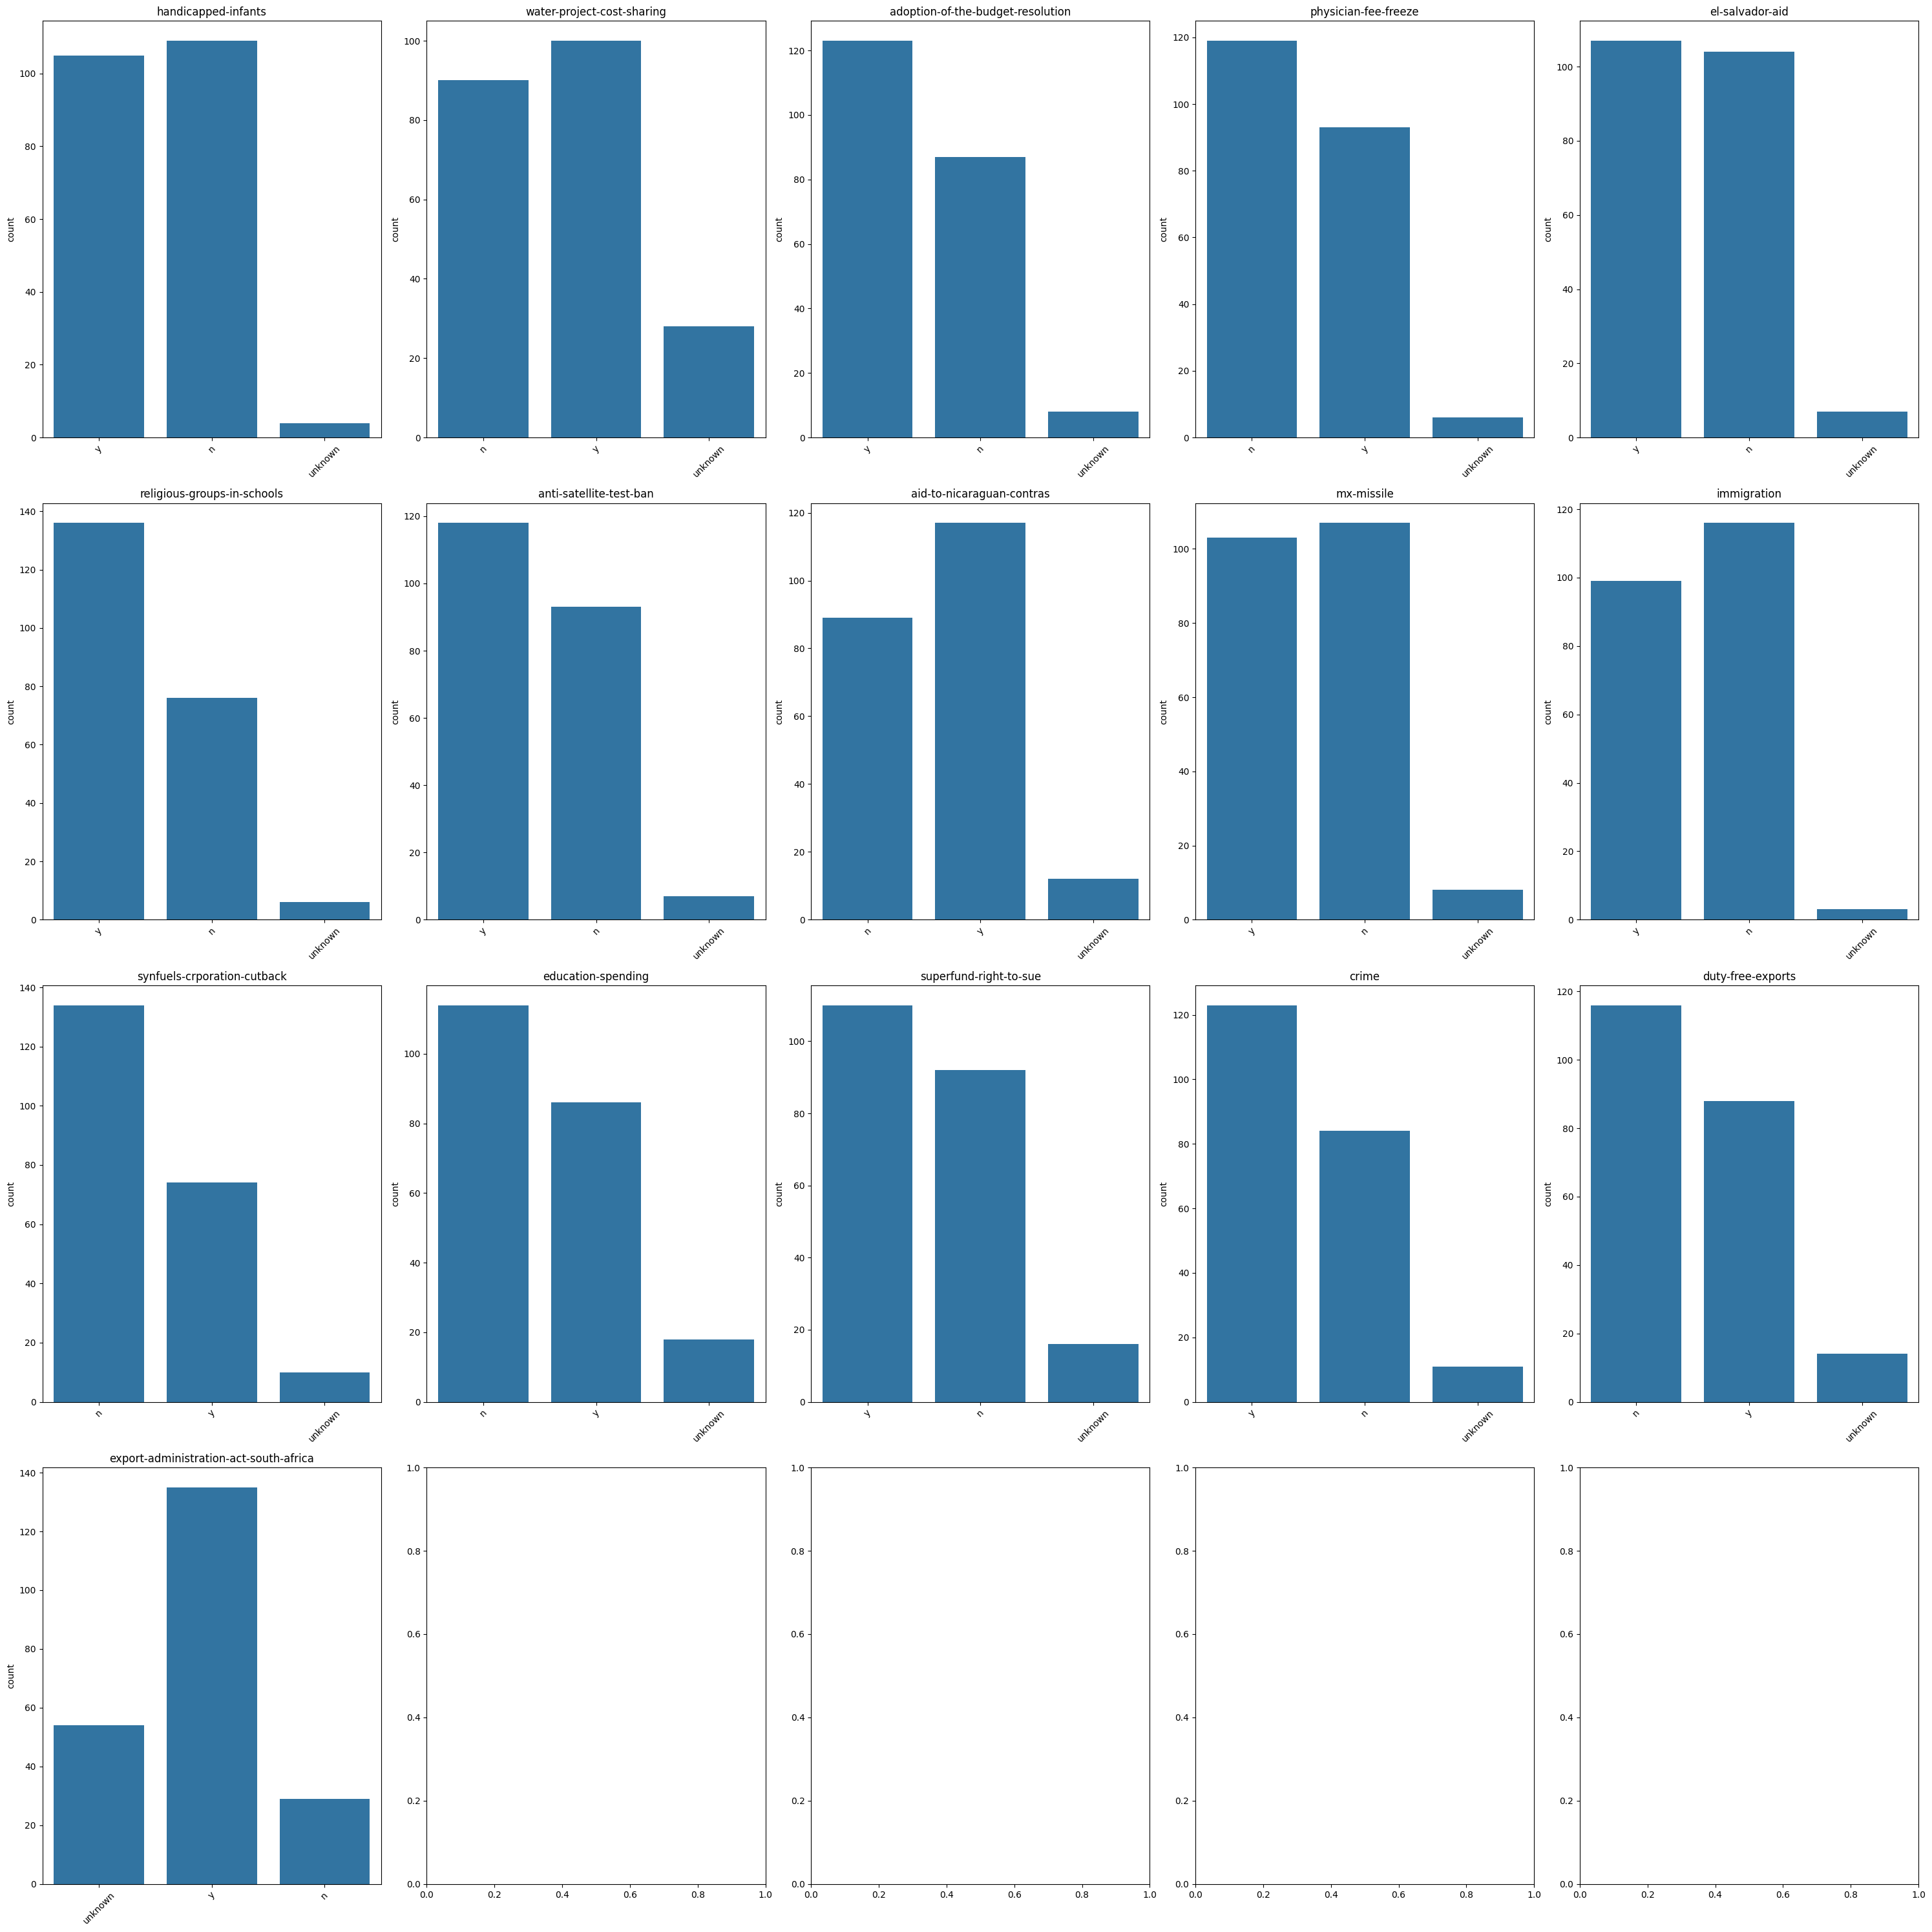

In [4]:
for col in X.columns[1:]:
    vals = X[col].value_counts()
    index = vals.index.tolist()
    vals = vals.values

    print("\n", col)
    try:
        print(f"{index[2]} : {vals[2]/ (vals[0] + vals[1] + vals[2])*100:.2f}% // {index[1]} : {vals[1]/ (vals[0] + vals[1] + vals[2])*100:.2f} % // {index[0]} : {vals[0]/ (vals[0] + vals[1] + vals[2])*100:.2f} %")
    except:
        print(f"{index[1]} : {vals[1]/ (vals[0] + vals[1])*100:.2f} % // {index[0]} : {vals[0]/ (vals[0] + vals[1])*100:.2f} %")

create_countplot(X)


#### Remark
Unknown values make up quite a big portion of the answers given sometimes. Ommiting them would result in a lot of loss of data and we already do not have a lot to begin with (218 entries).
I would opt to keeping them, maybe there is even some meaning in restraining from answering these questions/opting in/out of giving an opinion.

We also have to drop the ID columns as this does not contribute anything meaningful

## Working on the models

### Looking into encoding techniques

In [5]:
# three different preprocessing types
variant_A = Pipeline([
    ("encode", FunctionTransformer(encode_cat_values)),
    ("scaler", StandardScaler()) # has a minor affect (here on SVM and KNN, not decision tree) as it can only really take the variance of the 1s and 0s into account, relative distances are the saem
])

variant_A2 = Pipeline([
    ("encode", FunctionTransformer(encode_cat_values))
    ])

variant_B = Pipeline([
    ("encode", FunctionTransformer(encode_nan)),
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler())
])

variant_B2 = Pipeline([
    ("encode", FunctionTransformer(encode_nan)),
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler())
])

variant_B2 = Pipeline([
    ("encode", FunctionTransformer(encode_nan)),
    ("impute", SimpleImputer(strategy="most_frequent"))
])

# Onehotencoder transforms the values that are in one respective column into more columns. E.g. immigration column will become immigration_y and immigration_n with 0 and 1 respectively filled
variant_C = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), X.columns) # can pass all columns here because all are categorical
])

preprocessing_variants = {
    "Numeric_0.5_scaled": variant_A,
    "Numeric_0.5": variant_A2,
    "Numeric_imputed_scaled": variant_B,
    "Numeric_imputed": variant_B2,
    "OneHot": variant_C
}

# include crossvalidation as it is also possible to use other cross validation strategies by passing a cross validation iterator instead (https://scikit-learn.org/stable/modules/cross_validation.html)

# these three classifiers are choosen for all the different datasets for our team. Different vairables ofc.
classifiers = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', C=1.0), # gamma='scale'), >> Exclude here to compare results from preprocessing including, excluding StandardScaler!
    "DecisionTree": DecisionTreeClassifier(max_depth=None, random_state=21)
}

# Remark (copied from docu https://scikit-learn.org/stable/auto_examples/svm/plot_svm_kernels.html#sphx-glr-auto-examples-svm-plot-svm-kernels-py): 
# The radial basis function (RBF) kernel, also known as the Gaussian kernel, is the default kernel for Support Vector Machines in scikit-learn. 
# It measures similarity between two data points in infinite dimensions and then approaches classification by majority vote. 

# ========== Doing the machine learning ==========

results = []
cv = ShuffleSplit(n_splits=10, test_size=0.3, random_state=21)
for prep_name, prep_pipeline in preprocessing_variants.items():
    for clf_name, clf in classifiers.items():
        # to capture all the results
        fold_metrics = []
        
        # iterate through al the folds
        for fold, (train_idx, test_idx) in enumerate(cv.split(X, y_encoded)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

            pipe = Pipeline([
                ("preprocess", prep_pipeline),
                ("classifier", clf)
            ])

            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test) 
            # funfact as we were discussing potential leakage:
            # The pipeline only applies the preprocessing it learned from the training set 
            # e.g. imputation would be based on the training and the simply transpired through to the test. So no leakage!

            eval_dict = evaluate_run(
                name=f"{prep_name} + {clf_name} (fold {fold+1})",
                y_true=y_test,
                y_pred=y_pred,
                task_type="classification"
            )
            fold_metrics.append(eval_dict)
            
            # PLotting this only made sense in the first few iterations 
            #plot_confusion_matrix(
            #    classifier=f"{prep_name} + {clf_name} (fold {fold+1})", 
            #    y_true=y_test, 
            #    y_pred=y_pred,
            #    figsize=(2,2))

        # Aggregate across folds for stats 
        df_metrics = pd.DataFrame(fold_metrics)
        agg = df_metrics[['accuracy', 'balanced_accuracy', 'f1', 'precision', 'recall']].agg(['mean', 'std'])
        results.append({
            "Preprocessing": prep_name,
            "Classifier": clf_name,
            "accuracy_mean": agg.loc['mean', 'accuracy'],
            "accuracy_std": agg.loc['std', 'accuracy'],
            "b_accuracy_mean": agg.loc['mean', 'balanced_accuracy'],
            "b_accuracy_std": agg.loc['std', 'balanced_accuracy'],
            "f1_mean": agg.loc['mean', 'f1'],
            "f1_std": agg.loc['std', 'f1'],
            "precision_mean": agg.loc['mean', 'precision'],
            "recall_mean": agg.loc['mean', 'recall']
        })

results_df = pd.DataFrame(results)

In [6]:
agg

,accuracy,balanced_accuracy,f1,precision,recall
mean,0.937879,0.937027,0.935091,0.935038,0.937027
std,0.030679,0.030765,0.031483,0.031822,0.030765


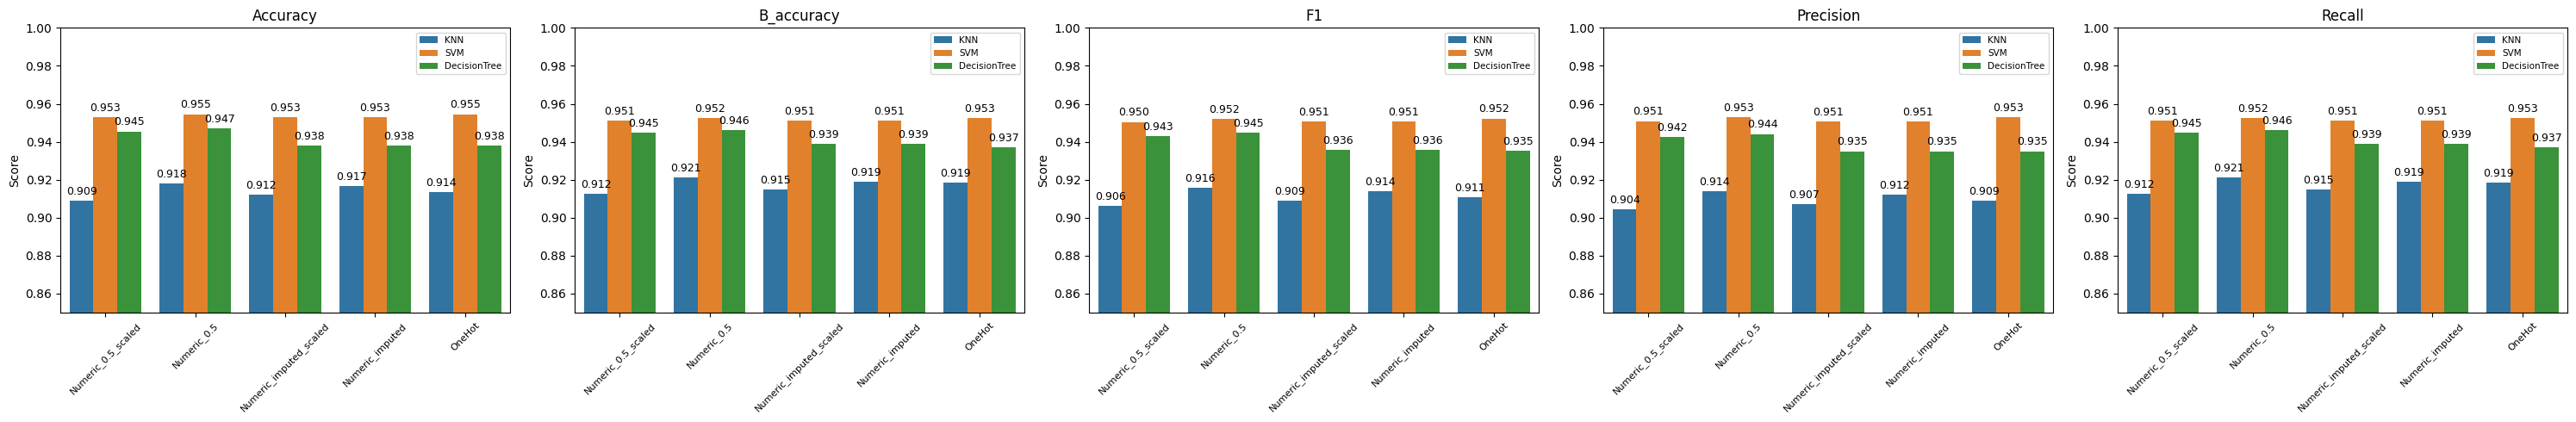


Cross-validation summary:


,Preprocessing,Classifier,accuracy_mean,accuracy_std,b_accuracy_mean,b_accuracy_std,f1_mean,f1_std,precision_mean,recall_mean
0,Numeric_0.5_scaled,KNN,0.909091,0.022587,0.912405,0.025687,0.906209,0.022622,0.904466,0.912405
6,Numeric_imputed_scaled,KNN,0.912121,0.022360,0.914716,0.025669,0.909058,0.022491,0.907307,0.914716
12,OneHot,KNN,0.913636,0.021487,0.918579,0.024736,0.910931,0.022202,0.908842,0.918579
9,Numeric_imputed,KNN,0.916667,0.025999,0.918819,0.029806,0.913844,0.025875,0.912066,0.918819
3,Numeric_0.5,KNN,0.918182,0.026915,0.921098,0.027748,0.915602,0.027320,0.913838,0.921098
8,Numeric_imputed_scaled,DecisionTree,0.937879,0.026195,0.938877,0.022001,0.935555,0.027017,0.935054,0.938877
11,Numeric_imputed,DecisionTree,0.937879,0.026195,0.938877,0.022001,0.935555,0.027017,0.935054,0.938877
14,OneHot,DecisionTree,0.937879,0.030679,0.937027,0.030765,0.935091,0.031483,0.935038,0.937027
2,Numeric_0.5_scaled,DecisionTree,0.945455,0.019165,0.944879,0.018375,0.943144,0.020035,0.942356,0.944879
5,Numeric_0.5,DecisionTree,0.946970,0.016366,0.946069,0.016169,0.944688,0.016997,0.944109,0.946069


In [7]:
metrics = ["accuracy_mean", "b_accuracy_mean", "f1_mean", "precision_mean", "recall_mean"]

fig, axes = plt.subplots(1, 5, figsize=(30, 5))
axes = axes.flatten() # turn into a 1D list for indexing

for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=results_df,
        x="Preprocessing",
        y=metric,
        hue="Classifier", 
        ax=ax
    )

    # add the numbers above the bars
    for container in ax.containers: # Each container holds the bars for one classifier (hue)
        ax.bar_label(
            container,
            fmt="%.3f",          
            label_type="edge",
            padding=3,
            fontsize=9
        )
    
    ax.set_title(metric.capitalize().replace("_mean", ""))
    ax.set_ylim(0.85, 1.0)
    ax.set_xlabel("")
    ax.set_ylabel("Score")        
    ax.tick_params(axis='x', labelrotation=45, labelsize=8)
    ax.legend(fontsize=7.5) 


plt.tight_layout()
plt.show()

print("\nCross-validation summary:")
results_df.sort_values(by=["accuracy_mean"])


### Remark
Scaling only hurts here one could say (even if minimally), as we have hard values (0 and 1) and make them continous with the scaling (based on their variance basically).
This can distort the meaning, as we can see here as it decreases performance

SVM seems to outperform here. Maybe because we are in a fairly high dimensional space (especially with OneHotEncoding) that SVM generally handles better, as it also downweights less impactful dimensions/features. SVM sort of does a feature selection in itself already (The ‘l2’ penalty is the standard used in SVM, which is not forcing zero coefficients for features but really close to zero!)

Anyhow, we now have to try to see whether active feature selection does something for the other classifiers here

### Looking into feature selection

In [8]:
# Wikipedia Info:
# In probability theory and information theory, the mutual information (MI) of two random variables is a measure of the mutual dependence between the two variables. 
# More specifically, it quantifies the "amount of information" (in units such as shannons (bits), nats or hartleys obtained about one random variable by observing 
# the other random variable. The concept of mutual information is intimately linked to that of entropy o.  a random variable, a fundamental notion in information theory
# that quantifies the expected "amount of information" held in a random variable.

selection_variants = {
    "None": None,
    "SelectKBest_mi_k": SelectKBest(chi2, k=5),
    "SelectFromModel_L1LogReg": SelectFromModel(
        LogisticRegression(penalty='l1', solver='saga', C=1.0, max_iter=5000),
        threshold='median'
    ),
    "SelectFromModel_RF": SelectFromModel(
        RandomForestClassifier(n_estimators=200, random_state=21), # n_estimator = The number of trees in the forest.
        threshold='median'
    ),
    "RFECV_LogReg": RFECV(
        estimator=LogisticRegression(max_iter=5000),
        step=1, cv=3, scoring='f1', min_features_to_select=5
    )
}

# using "best" encoder from before
# Onehotencoder transforms the values that are in one respective column into more columns. E.g. immigration column will become immigration_y and immigration_n with 0 and 1 respectively filled
encoder = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), X.columns) # can pass all columns here because all are categorical
])

classifiers = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', C=1.0), # gamma='scale'), >> Exclude here to compare results from preprocessing including, excluding StandardScaler!
    "DecisionTree": DecisionTreeClassifier(max_depth=None, random_state=21)
}

# Remark (copied from docu https://scikit-learn.org/stable/auto_examples/svm/plot_svm_kernels.html#sphx-glr-auto-examples-svm-plot-svm-kernels-py): 
# The radial basis function (RBF) kernel, also known as the Gaussian kernel, is the default kernel for Support Vector Machines in scikit-learn. 
# It measures similarity between two data points in infinite dimensions and then approaches classification by majority vote. 

# Doing the machine learning

results = []
cv = ShuffleSplit(n_splits=10, test_size=0.3, random_state=21)
for sel_name, sel in selection_variants.items():
    for clf_name, clf in classifiers.items():
        # to capture all the results
        fold_metrics = []
        
        # iterate through al the folds
        for fold, (train_idx, test_idx) in enumerate(cv.split(X, y_encoded)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

            if sel is not None:
                pipe = Pipeline([
                    ("preprocess", encoder),
                    ("f_selection", sel),
                    ("classifier", clf)
                ])
            else:
                pipe = Pipeline([
                    ("preprocess", encoder),
                    ("classifier", clf)
                ])

            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test) 
            # funfact as we were discussing potential leakage:
            # The pipeline only applies the preprocessing it learned from the training set 
            # e.g. imputation would be based on the training and the simply transpired through to the test. So no leakage!

            eval_dict = evaluate_run(
                name=f"{sel_name} + {clf_name} (fold {fold+1})",
                y_true=y_test,
                y_pred=y_pred,
                task_type="classification"
            )
            fold_metrics.append(eval_dict)

        # Aggregate across folds for stats 
        df_metrics = pd.DataFrame(fold_metrics)
        agg = df_metrics[['accuracy', 'balanced_accuracy', 'f1', 'precision', 'recall']].agg(['mean', 'std'])
        results.append({
            "Feature_Selection": sel_name,
            "Classifier": clf_name,
            "accuracy_mean": agg.loc['mean', 'accuracy'],
            "accuracy_std": agg.loc['std', 'accuracy'],
            "b_accuracy_mean": agg.loc['mean', 'balanced_accuracy'],
            "b_accuracy_std": agg.loc['std', 'balanced_accuracy'],
            "f1_mean": agg.loc['mean', 'f1'],
            "f1_std": agg.loc['std', 'f1'],
            "precision_mean": agg.loc['mean', 'precision'],
            "recall_mean": agg.loc['mean', 'recall']
        })

results_df = pd.DataFrame(results)


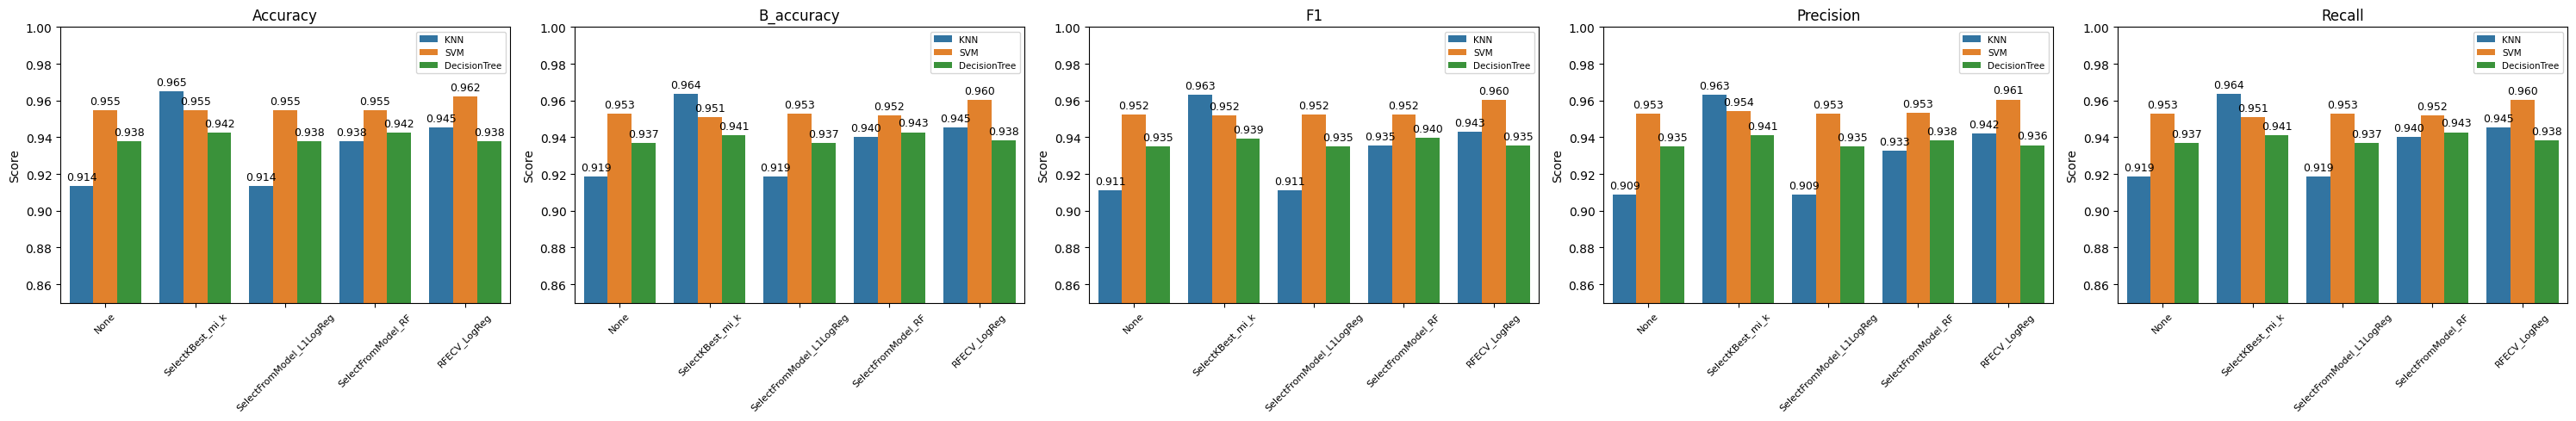


Cross-validation summary:


,Feature_Selection,Classifier,accuracy_mean,accuracy_std,b_accuracy_mean,b_accuracy_std,f1_mean,f1_std,precision_mean,recall_mean
0,None,KNN,0.913636,0.021487,0.918579,0.024736,0.910931,0.022202,0.908842,0.918579
6,SelectFromModel_L1LogReg,KNN,0.913636,0.021487,0.918579,0.024736,0.910931,0.022202,0.908842,0.918579
9,SelectFromModel_RF,KNN,0.937879,0.020762,0.940145,0.022956,0.935410,0.022237,0.932699,0.940145
2,None,DecisionTree,0.937879,0.030679,0.937027,0.030765,0.935091,0.031483,0.935038,0.937027
8,SelectFromModel_L1LogReg,DecisionTree,0.937879,0.030679,0.937027,0.030765,0.935091,0.031483,0.935038,0.937027
14,RFECV_LogReg,DecisionTree,0.937879,0.033842,0.938360,0.029196,0.935332,0.034710,0.935711,0.938360
11,SelectFromModel_RF,DecisionTree,0.942424,0.021188,0.942706,0.023402,0.939679,0.023211,0.938298,0.942706
5,SelectKBest_mi_k,DecisionTree,0.942424,0.029276,0.941146,0.032401,0.939280,0.031721,0.941069,0.941146
12,RFECV_LogReg,KNN,0.945455,0.025950,0.945391,0.029450,0.943000,0.027909,0.941955,0.945391
1,None,SVM,0.954545,0.017495,0.952662,0.020875,0.952276,0.018802,0.952766,0.952662


In [9]:
metrics = ["accuracy_mean", "b_accuracy_mean", "f1_mean", "precision_mean", "recall_mean"]

fig, axes = plt.subplots(1, 5, figsize=(30, 5))
axes = axes.flatten() # turn into a 1D list for indexing

for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=results_df,
        x="Feature_Selection",
        y=metric,
        hue="Classifier",
        ax=ax
    )

    # add the numbers above the bars
    for container in ax.containers: # Each container holds the bars for one classifier (hue)
        ax.bar_label(
            container,
            fmt="%.3f",          
            label_type="edge",
            padding=3,
            fontsize=9
        )
    
    ax.set_title(metric.capitalize().replace("_mean", ""))
    ax.set_ylim(0.85, 1.0)
    ax.set_xlabel("")
    ax.set_ylabel("Score")        
    ax.tick_params(axis='x', labelrotation=45, labelsize=8)
    ax.legend(fontsize=7.5) 


plt.tight_layout()
plt.show()

print("\nCross-validation summary:")
results_df.sort_values(by=["accuracy_mean"])


### Remarks
We can see that feature selection helps KNN dramatically if we do OneHotEncoding, which makes sense since fewer dimensions apparently help avoid a thing called Curse of Dimensionality 
(https://en.wikipedia.org/wiki/Curse_of_dimensionality). This basically means that with an increase in dimensionality with e.g. One-Hot encoding and a steady sample of data, we get a concentration of values as the distances do not work as we are used to from 3dimensional space. It gets clustered and makes the term closeness becomes a bit fuzzy and hence KNN is not as effective any more. Reducing the features before encoding then obviously helps mitigate that issue.

Ones we use the other encoding technique (0, 0.5, 1) we can see that this effect is not as dramatic anymore, although still noticeable. SVM not being affected makes sense since it basically does some feature selection itself!

### Combining everything!

In [ ]:
def nested_selection_search(
    X: pd.DataFrame,
    y: pd.Series,
    preprocessor: BaseEstimator,
    selector_grid_dict: Dict[str, Tuple[Callable[..., BaseEstimator], Dict[str, Iterable[Any]]]],
    classifier_grid_dict: Dict[str, Tuple[Callable[..., BaseEstimator], Dict[str, Iterable[Any]]]],
    outer_cv: ShuffleSplit | None = None,
    inner_cv: StratifiedKFold | None = None,
    scoring: str = 'f1', # f1 mainly because its a balanced score, not much more thought behind that
    random_state: int = 21
) -> Tuple[pd.DataFrame, pd.DataFrame, List[GridSearchCV]]:
    """
    Nested CV search over selector + classifier hyperparameters.

    Parameters
    ----------
    X
        Feature DataFrame
    y
        Target series (must be already encoded labels!)
    preprocessor
        Preprocessor
    selector_grid_dict
        The str links to (constructor_callable, param_grid)
        - constructor_callable: callable that returns an unfitted selector when called with no args
        - param_grid: dict mapping of selector names to potential values
    classifier_grid_dict
        The str links to (constructor_callable, param_grid)
        - constructor_callable: callable that returns an unfitted classifier when called with no args
        - param_grid: dict mapping of classifier variables to potential values
    outer_cv
        Outer CV as done in the beginning
    inner_cv
        Inner CV splitter used by GridSearchCV and is only used to tune hyperparameters on the outer training fold only.
    scoring
        Metric used by GridSearchCV ('f1' here as default).
    random_state
        Seed

    Returns
    -------
    results_df
        DataFrame with all used variables for the model including various metrics as before
    feature_freq_df
        Aggregated frequency table across all selections
    grid_search_objects
        List of GridSearchCV objects created for Debugging/Analysis
    """

    # defaults
    if outer_cv is None:
        outer_cv = ShuffleSplit(n_splits=5, test_size=0.3, random_state=random_state)
    if inner_cv is None:
        inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)

    results: List[Dict[str, Any]] = []
    grid_objects: List[GridSearchCV] = []

    # Initiate the combo of selectors, classifiers for thr GridSearchCV
    combo_list = []
    for sel_label, (sel_ctor, sel_param_grid) in selector_grid_dict.items():
        for clf_label, (clf_ctor, clf_param_grid) in classifier_grid_dict.items():
            # prefix param names for the pipeline (the steps are called "selector", "classifier"; hence we need to add the prefixes)
            param_grid: Dict[str, Iterable[Any]] = {}
            sel_param_grid = sel_param_grid or {}
            clf_param_grid = clf_param_grid or {}
            for k, v in sel_param_grid.items():
                param_grid[f"selector__{k}"] = v
            for k, v in clf_param_grid.items():
                param_grid[f"classifier__{k}"] = v

            combo_list.append({
                "sel_label": sel_label,
                "clf_label": clf_label,
                "sel_ctor": sel_ctor,
                "clf_ctor": clf_ctor,
                "param_grid": param_grid
            })

    # iterate through the combos now
    for combo in combo_list:
        sel_label = combo["sel_label"]
        clf_label = combo["clf_label"]
        param_grid = combo["param_grid"]

        for outer_fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

            # instantiate "fresh" selector and classifier for each fold 
            selector = combo["sel_ctor"]()
            classifier = combo["clf_ctor"]()

            pipe = Pipeline([
                ("preprocess", preprocessor),
                ("selector", selector),
                ("classifier", classifier)
            ])
            
            # gridwork
            grid = GridSearchCV(
                estimator=pipe,
                param_grid=param_grid,
                cv=inner_cv,
                scoring=scoring,
                refit=True,
                return_train_score=False
            )
            grid.fit(X_train, y_train)
            best_pipe = grid.best_estimator_
            best_params = grid.best_params_
            grid_objects.append(grid)

            # Evaluate on outer(!) test fold
            y_pred = best_pipe.predict(X_test)

            eval_dict = evaluate_run(
                name=f"{sel_label} + {clf_label} (fold {outer_fold+1})",
                y_true=y_test,
                y_pred=y_pred,
                task_type="classification"
            )

            # get transformed feature names
            preproc = best_pipe.named_steps["preprocess"]
            transformed_names = preproc.get_feature_names_out(X.columns)
            
            # get the selected features 
            sel_step = best_pipe.named_steps.get("selector", None)
            selected_features: List[str]
            if sel_step is None:
                selected_features = list(transformed_names)
            else:
                # normally you get a mask from the selector with get_support() method (returns boolean array telling you which columns to keep/not to keep)
                if hasattr(sel_step, "get_support"):
                    mask = sel_step.get_support()
                    selected_features = list(np.array(transformed_names)[mask])
                elif hasattr(sel_step, "estimator_") and hasattr(sel_step.estimator_, "coef_"):
                    coef = sel_step.estimator_.coef_
                    mask = np.any(np.abs(coef) > 0, axis=0)
                    selected_features = list(np.array(transformed_names)[mask])
                # RFECV and have it in support_ apparently as well
                elif hasattr(sel_step, "support_"):
                    mask = sel_step.support_
                    selected_features = list(np.array(transformed_names)[mask])
                else:
                    selected_features = []

            # record results
            eval_dict.update({
                "outer_fold": outer_fold,
                "sel_label": sel_label,
                "sel_step": sel_step,
                "clf_label": clf_label,
                "best_params": best_params,
                "n_selected": len(selected_features),
                "selected_features": selected_features
            })
            results.append(eval_dict)

    results_df = pd.DataFrame(results)

    all_selected = [feat for feats in results_df.get("selected_features", []) for feat in feats]
    freq = Counter(all_selected)
    total_runs = max(1, len(results_df))
    freq_items = [(feat, cnt, cnt / total_runs) for feat, cnt in freq.most_common()]
    feature_freq_df = pd.DataFrame(freq_items, columns=["feature", "selected_count", "selected_fraction"])

    return results_df, feature_freq_df, grid_objects


In [ ]:
selector_grid_dict = {
    "SelectKBest_mi": (lambda: SelectKBest(chi2, k=5), {"k":[5,10,20]}),
    "L1_LogReg_SFM": (lambda: SelectFromModel(LogisticRegression(penalty='l1', solver='saga', max_iter=5000)), {"threshold":['median'], "estimator__C":[0.1,1.0]}),
    "RF_SFM": (lambda: SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=0)), {"threshold":['median'], "estimator__n_estimators":[100,200]})
}

classifier_grid_dict = {
    "SVM_RBF": (lambda: SVC(kernel='rbf'), {"C":[0.1,1.0]}),
    "KNN": (lambda: KNeighborsClassifier(), {"n_neighbors":[3,5,7]}),
    "DecisionTree": (lambda: DecisionTreeClassifier(random_state=21), {"max_depth":[None,3,5,7]})
}

# Remark (copied from docu https://scikit-learn.org/stable/auto_examples/svm/plot_svm_kernels.html#sphx-glr-auto-examples-svm-plot-svm-kernels-py): 
# The radial basis function (RBF) kernel, also known as the Gaussian kernel, is the default kernel for Support Vector Machines in scikit-learn. 
# It measures similarity between two data points in infinite dimensions and then approaches classification by majority vote. 


results_df, feature_freq_df, grid_objs = nested_selection_search(
    X=X,
    y=y_encoded,
    preprocessor=encoder, # remark: chosen because it performed best before.
    selector_grid_dict=selector_grid_dict,
    classifier_grid_dict=classifier_grid_dict,
    outer_cv=ShuffleSplit(n_splits=10, test_size=0.3, random_state=21),
    inner_cv=StratifiedKFold(n_splits=3),
    scoring='f1',
    random_state=21
)

### Analysis of results

In [12]:
feature_freq_df

,feature,selected_count,selected_fraction
0,cat__adoption-of-the-budget-resolution_n,90,1.000000
1,cat__physician-fee-freeze_n,90,1.000000
2,cat__physician-fee-freeze_y,90,1.000000
3,cat__el-salvador-aid_y,88,0.977778
4,cat__education-spending_y,85,0.944444
5,cat__el-salvador-aid_n,77,0.855556
6,cat__adoption-of-the-budget-resolution_y,70,0.777778
7,cat__aid-to-nicaraguan-contras_y,70,0.777778
8,cat__crime_n,69,0.766667
9,cat__aid-to-nicaraguan-contras_n,68,0.755556


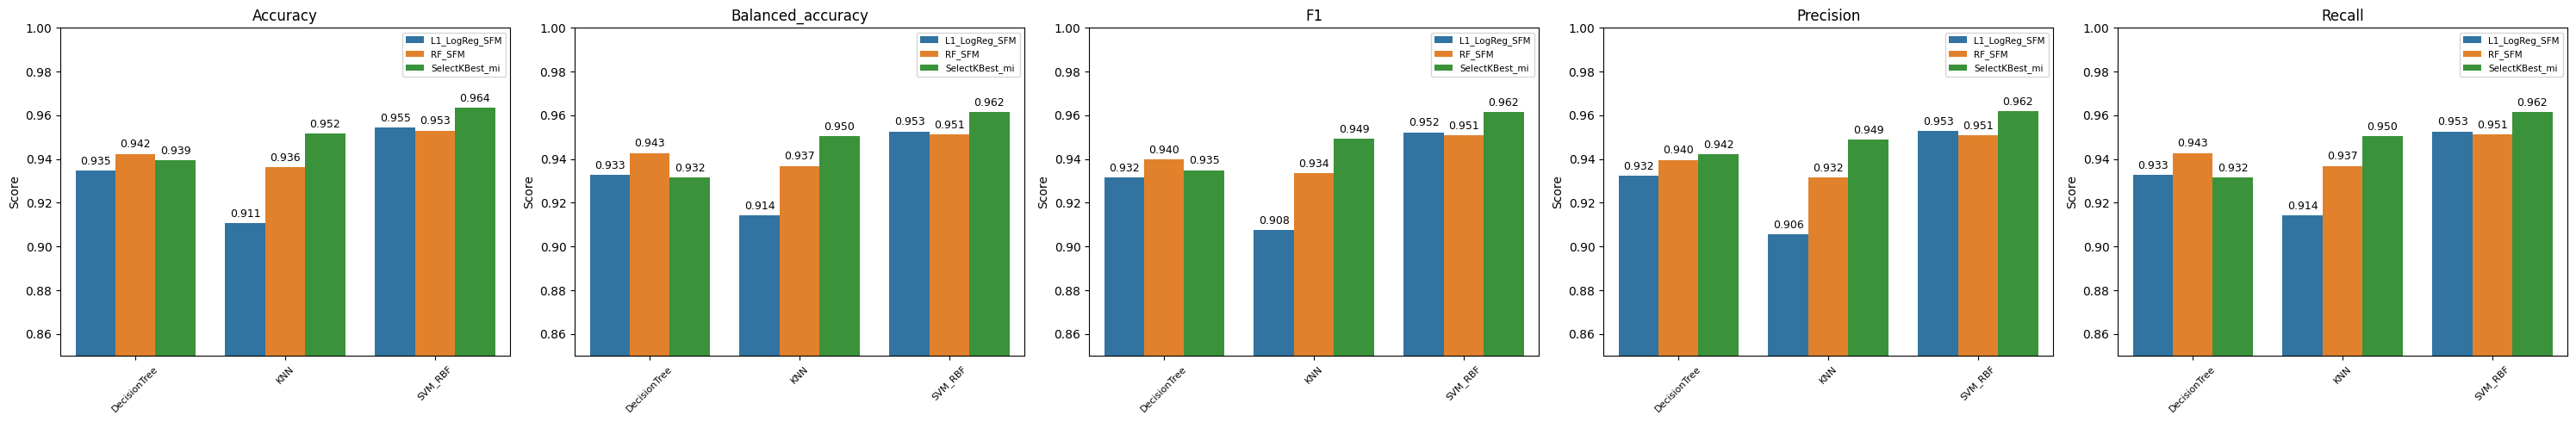

,sel_label,clf_label,accuracy_mean,balanced_accuracy_mean,f1_mean,precision_mean,recall_mean,n_selected_mean,accuracy_std,balanced_accuracy_std,f1_std,precision_std,recall_std,n_selected_std
8,SelectKBest_mi,SVM_RBF,0.963636,0.961572,0.961558,0.961842,0.961572,9.0,0.020453,0.023546,0.022293,0.021227,0.023546,6.146363
2,L1_LogReg_SFM,SVM_RBF,0.954545,0.952662,0.952276,0.952766,0.952662,47.7,0.017495,0.020875,0.018802,0.017192,0.020875,0.674949
5,RF_SFM,SVM_RBF,0.953030,0.951412,0.950722,0.950859,0.951412,23.9,0.018140,0.021482,0.019451,0.017885,0.021482,0.316228
7,SelectKBest_mi,KNN,0.951515,0.950325,0.949198,0.948829,0.950325,9.5,0.025554,0.027983,0.026972,0.026255,0.027983,7.245688
3,RF_SFM,DecisionTree,0.942424,0.942787,0.939875,0.939644,0.942787,23.9,0.025554,0.025711,0.026586,0.028991,0.025711,0.316228
6,SelectKBest_mi,DecisionTree,0.939394,0.931644,0.934954,0.942259,0.931644,6.5,0.034254,0.043019,0.037933,0.028024,0.043019,2.415229
4,RF_SFM,KNN,0.936364,0.936926,0.933574,0.931649,0.936926,23.9,0.026533,0.030481,0.028394,0.027676,0.030481,0.316228
0,L1_LogReg_SFM,DecisionTree,0.934848,0.932778,0.931664,0.932423,0.932778,47.7,0.030345,0.029804,0.031301,0.032489,0.029804,0.674949
1,L1_LogReg_SFM,KNN,0.910606,0.914155,0.907694,0.905508,0.914155,47.7,0.018140,0.023367,0.018439,0.016646,0.023367,0.674949


In [17]:
# aggregated metrics per combo
agg = results_df.groupby(["sel_label","clf_label"]).agg({
    "accuracy":"mean",
    "balanced_accuracy":"mean",
    "f1":"mean",
    "precision":"mean",
    "recall":"mean",
    "n_selected":"mean"
}).rename(columns=lambda c: c + "_mean")
# also keep std (esp. interesting for the n_selected!)
agg_std = results_df.groupby(["sel_label","clf_label"]).agg({
    "accuracy":"std","balanced_accuracy":"std","f1":"std","precision":"std","recall":"std","n_selected":"std"
}).rename(columns=lambda c: c + "_std")
summary_table = pd.concat([agg, agg_std], axis=1).reset_index()


metrics = ["accuracy_mean", "balanced_accuracy_mean", "f1_mean", "precision_mean", "recall_mean"]

fig, axes = plt.subplots(1, 5, figsize=(30, 5))
axes = axes.flatten() # turn into a 1D list for indexing

for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=agg,
        x="clf_label",
        y=metric,
        hue="sel_label",
        ax=ax
    )

    # add the numbers above the bars
    for container in ax.containers: # Each container holds the bars for one classifier (hue)
        ax.bar_label(
            container,
            fmt="%.3f",          
            label_type="edge",
            padding=3,
            fontsize=9
        )
    
    ax.set_title(metric.capitalize().replace("_mean", ""))
    ax.set_ylim(0.85, 1.0)
    ax.set_xlabel("")
    ax.set_ylabel("Score")        
    ax.tick_params(axis='x', labelrotation=45, labelsize=8)
    ax.legend(fontsize=7.5) 


plt.tight_layout()
plt.show()

display(summary_table.sort_values(by="f1_mean", ascending=False).head(20))


/var/folders/dr/mfvlj90n1fb8j8j9xmz28dzc0000gn/T/ipykernel_83669/3521576931.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_df.loc[:,'original_var'] = top_df.loc[:, 'feature'].apply(original_from_transformed)


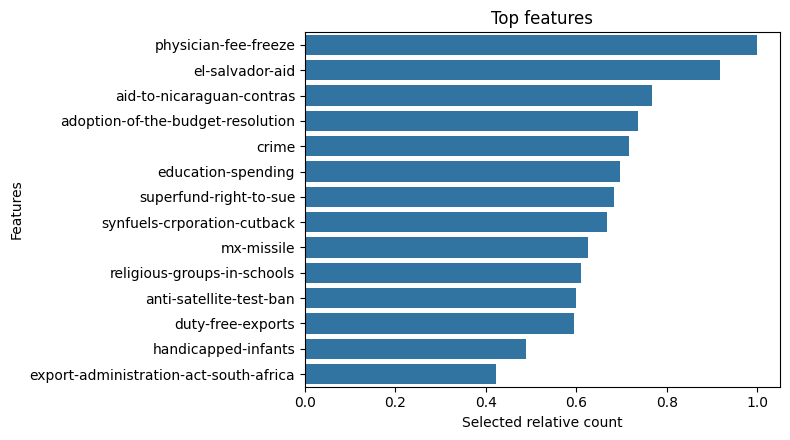

,selected_count_sum,selected_count_max,selected_fraction_mean,selected_fraction_max
original_var,,,,
physician-fee-freeze,180,90,1.000000,1.000000
el-salvador-aid,165,88,0.916667,0.977778
aid-to-nicaraguan-contras,138,70,0.766667,0.777778
adoption-of-the-budget-resolution,199,90,0.737037,1.000000
crime,129,69,0.716667,0.766667
education-spending,188,85,0.696296,0.944444
superfund-right-to-sue,123,62,0.683333,0.688889
synfuels-crporation-cutback,120,60,0.666667,0.666667
mx-missile,169,65,0.625926,0.722222


In [26]:
top_n = 30
top_df = feature_freq_df.head(top_n)

def original_from_transformed(name: str) -> str:
    if name.startswith('cat__'):
        s = name[len('cat__'):]
        orig = s.split('_')[0]
        return orig
    return name

top_df.loc[:,'original_var'] = top_df.loc[:, 'feature'].apply(original_from_transformed)

# group by original variable
grouped = top_df.groupby('original_var').agg({
    'selected_count': ['sum', 'max'],
    'selected_fraction': ['mean', 'max']
})
grouped.columns = ['_'.join(col) for col in grouped.columns]
grouped = grouped.sort_values('selected_fraction_mean', ascending=False)

# barplot of top features
plt.figure(figsize=(8, max(4, top_n*0.15)))
sns.barplot(data=grouped, x='selected_fraction_mean', y='original_var')
plt.xlabel('Selected relative count')
plt.ylabel('Features')

plt.title(f'Top features')
plt.tight_layout()
plt.show()

display(grouped.head(40))


In [22]:
display(top_df)

,feature,selected_count,selected_fraction,original_var
0,cat__adoption-of-the-budget-resolution_n,90,1.000000,adoption-of-the-budget-resolution
1,cat__physician-fee-freeze_n,90,1.000000,physician-fee-freeze
2,cat__physician-fee-freeze_y,90,1.000000,physician-fee-freeze
3,cat__el-salvador-aid_y,88,0.977778,el-salvador-aid
4,cat__education-spending_y,85,0.944444,education-spending
5,cat__el-salvador-aid_n,77,0.855556,el-salvador-aid
6,cat__adoption-of-the-budget-resolution_y,70,0.777778,adoption-of-the-budget-resolution
7,cat__aid-to-nicaraguan-contras_y,70,0.777778,aid-to-nicaraguan-contras
8,cat__crime_n,69,0.766667,crime
9,cat__aid-to-nicaraguan-contras_n,68,0.755556,aid-to-nicaraguan-contras


In [15]:
results_df.sort_values(by="balanced_accuracy", ascending=False).head(15)

,id,name,task_type,accuracy,balanced_accuracy,f1,precision,recall,conf_matr,outer_fold,sel_label,sel_step,clf_label,best_params,n_selected,selected_features
3,9d2d4a93-b7e6-4091-8ef7-7ee4a9e8cff7,SelectKBest_mi + SVM_RBF (fold 4),classification,0.984848,0.987805,0.984023,0.980769,0.987805,"[[40, 1], [0, 25]]",3,SelectKBest_mi,"SelectKBest(k=5, score_func=<function chi2 at ...",SVM_RBF,"{'classifier__C': 0.1, 'selector__k': 5}",5,"[cat__adoption-of-the-budget-resolution_n, cat..."
20,7bf7d0be-2370-493d-9151-fc83b8acedbe,SelectKBest_mi + DecisionTree (fold 1),classification,0.984848,0.986486,0.984676,0.983333,0.986486,"[[36, 1], [0, 29]]",0,SelectKBest_mi,"SelectKBest(k=5, score_func=<function chi2 at ...",DecisionTree,"{'classifier__max_depth': 3, 'selector__k': 5}",5,"[cat__adoption-of-the-budget-resolution_n, cat..."
67,311f005d-e2e2-4fab-8fbe-10a8130a3514,RF_SFM + SVM_RBF (fold 8),classification,0.984848,0.984848,0.984845,0.985294,0.984848,"[[32, 1], [0, 33]]",7,RF_SFM,SelectFromModel(estimator=RandomForestClassifi...,SVM_RBF,"{'classifier__C': 1.0, 'selector__estimator__n...",24,"[cat__adoption-of-the-budget-resolution_n, cat..."
7,cd2ef5ec-c082-44fd-badc-ea5df645e695,SelectKBest_mi + SVM_RBF (fold 8),classification,0.984848,0.984848,0.984845,0.985294,0.984848,"[[32, 1], [0, 33]]",7,SelectKBest_mi,"SelectKBest(k=5, score_func=<function chi2 at ...",SVM_RBF,"{'classifier__C': 0.1, 'selector__k': 5}",5,"[cat__adoption-of-the-budget-resolution_n, cat..."
37,0d3f067a-6c0f-4a5b-8b42-abc209095942,L1_LogReg_SFM + SVM_RBF (fold 8),classification,0.984848,0.984848,0.984845,0.985294,0.984848,"[[32, 1], [0, 33]]",7,L1_LogReg_SFM,SelectFromModel(estimator=LogisticRegression(C...,SVM_RBF,"{'classifier__C': 1.0, 'selector__estimator__C...",48,"[cat__handicapped-infants_n, cat__handicapped-..."
57,8d628b38-91e1-4ae9-9f6d-4203ea3a764b,L1_LogReg_SFM + DecisionTree (fold 8),classification,0.984848,0.984848,0.984845,0.985294,0.984848,"[[33, 0], [1, 32]]",7,L1_LogReg_SFM,SelectFromModel(estimator=LogisticRegression(C...,DecisionTree,"{'classifier__max_depth': None, 'selector__est...",48,"[cat__handicapped-infants_n, cat__handicapped-..."
14,9e3db0ca-42ed-4715-99d9-32b96313f42b,SelectKBest_mi + KNN (fold 5),classification,0.984848,0.984375,0.984817,0.985714,0.984375,"[[34, 0], [1, 31]]",4,SelectKBest_mi,"SelectKBest(k=5, score_func=<function chi2 at ...",KNN,"{'classifier__n_neighbors': 7, 'selector__k': 5}",5,"[cat__adoption-of-the-budget-resolution_n, cat..."
4,b656cdfa-5ad9-4068-9d1c-2bdb5d501cda,SelectKBest_mi + SVM_RBF (fold 5),classification,0.984848,0.984375,0.984817,0.985714,0.984375,"[[34, 0], [1, 31]]",4,SelectKBest_mi,"SelectKBest(k=5, score_func=<function chi2 at ...",SVM_RBF,"{'classifier__C': 0.1, 'selector__k': 5}",5,"[cat__adoption-of-the-budget-resolution_n, cat..."
24,68685f4d-4fd2-4d6f-a2a1-a139179fcc2e,SelectKBest_mi + DecisionTree (fold 5),classification,0.984848,0.984375,0.984817,0.985714,0.984375,"[[34, 0], [1, 31]]",4,SelectKBest_mi,"SelectKBest(k=5, score_func=<function chi2 at ...",DecisionTree,"{'classifier__max_depth': 3, 'selector__k': 5}",5,"[cat__adoption-of-the-budget-resolution_n, cat..."
33,ab346121-f4ca-4530-96cd-43736e282d9a,L1_LogReg_SFM + SVM_RBF (fold 4),classification,0.969697,0.975610,0.968269,0.962963,0.975610,"[[39, 2], [0, 25]]",3,L1_LogReg_SFM,SelectFromModel(estimator=LogisticRegression(C...,SVM_RBF,"{'classifier__C': 1.0, 'selector__estimator__C...",48,"[cat__handicapped-infants_n, cat__handicapped-..."


In [24]:
# aggregated metrics per combo

results_df["best_params_str"] = results_df["best_params"].astype(str)

agg = results_df.groupby(["sel_label","clf_label", "best_params_str"]).agg({
    "accuracy":"mean",
    "balanced_accuracy":"mean",
    "f1":"mean",
    "precision":"mean",
    "recall":"mean",
    "n_selected":"mean"
}).rename(columns=lambda c: c + "_mean")
# also keep std (esp. interesting for the n_selected!)
agg_std = results_df.groupby(["sel_label","clf_label", "best_params_str"]).agg({
    "accuracy":"std","balanced_accuracy":"std","f1":"std","precision":"std","recall":"std","n_selected":"std"
}).rename(columns=lambda c: c + "_std")

summary_table = pd.concat([agg, agg_std], axis=1).reset_index()
display(summary_table.sort_values(by="f1_mean", ascending=False))


,sel_label,clf_label,best_params_str,accuracy_mean,balanced_accuracy_mean,f1_mean,precision_mean,recall_mean,n_selected_mean,accuracy_std,balanced_accuracy_std,f1_std,precision_std,recall_std,n_selected_std
24,SelectKBest_mi,KNN,"{'classifier__n_neighbors': 7, 'selector__k': 5}",0.984848,0.984375,0.984817,0.985714,0.984375,5.000000,NaN,NaN,NaN,NaN,NaN,NaN
18,SelectKBest_mi,DecisionTree,"{'classifier__max_depth': 3, 'selector__k': 5}",0.984848,0.985431,0.984747,0.984524,0.985431,5.000000,0.000000,0.001493,0.000100,0.001684,0.001493,0.000000
22,SelectKBest_mi,KNN,"{'classifier__n_neighbors': 5, 'selector__k': 5}",0.969697,0.969245,0.969245,0.969245,0.969245,5.000000,NaN,NaN,NaN,NaN,NaN,NaN
26,SelectKBest_mi,SVM_RBF,"{'classifier__C': 1.0, 'selector__k': 10}",0.969697,0.967285,0.967285,0.967285,0.967285,10.000000,0.000000,0.001946,0.001946,0.001946,0.001946,0.000000
25,SelectKBest_mi,SVM_RBF,"{'classifier__C': 0.1, 'selector__k': 5}",0.967172,0.964834,0.965399,0.966378,0.964834,5.000000,0.024274,0.028964,0.026828,0.024757,0.028964,0.000000
6,RF_SFM,DecisionTree,"{'classifier__max_depth': 3, 'selector__estima...",0.962121,0.959368,0.960883,0.962653,0.959368,24.000000,0.010714,0.014608,0.012464,0.009961,0.014608,0.000000
14,RF_SFM,KNN,"{'classifier__n_neighbors': 7, 'selector__esti...",0.954545,0.954044,0.954451,0.955300,0.954044,24.000000,NaN,NaN,NaN,NaN,NaN,NaN
23,SelectKBest_mi,KNN,"{'classifier__n_neighbors': 7, 'selector__k': 20}",0.954545,0.963415,0.952711,0.946429,0.963415,20.000000,NaN,NaN,NaN,NaN,NaN,NaN
15,RF_SFM,SVM_RBF,"{'classifier__C': 1.0, 'selector__estimator__n...",0.954545,0.952967,0.952444,0.952670,0.952967,24.000000,0.017495,0.018801,0.018037,0.017492,0.018801,0.000000
5,L1_LogReg_SFM,SVM_RBF,"{'classifier__C': 1.0, 'selector__estimator__C...",0.954545,0.952662,0.952276,0.952766,0.952662,47.700000,0.017495,0.020875,0.018802,0.017192,0.020875,0.674949
